# Mini Project 2

# Reusable Customer Churn Prediction Pipeline using scikit-learn

## Student Name

Sasi Rekha

## Dataset

E-Commerce Customer Churn Dataset

## Objective

Build a reusable Machine Learning Pipeline using scikit-learn to predict customer churn.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_excel(
    r"C:\Users\ELCOT\Desktop\TASK 5_Customer_Churn_Pipeline\Dataset\E Commerce Dataset.xlsx",
    sheet_name="E Comm",
)

In [6]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [9]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 5630
Columns : 20


In [11]:
df.isnull().sum()

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

In [12]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [13]:
print(df["Churn"].value_counts())

Churn
0    4682
1     948
Name: count, dtype: int64


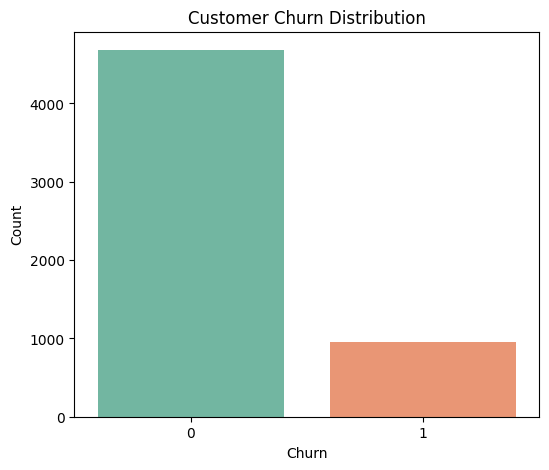

In [14]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Churn",
    palette="Set2"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

In [15]:
#Remove CustomerID
df = df.drop("CustomerID", axis=1)

In [16]:
df.head()

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [17]:
#Features and Target

X = df.drop("Churn", axis=1)

y = df["Churn"]

In [18]:
print(X.shape)
print(y.shape)

(5630, 18)
(5630,)


In [19]:
#Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [20]:
print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

Training Data : (4504, 18)
Testing Data  : (1126, 18)


In [21]:
#Identify Numerical Columns

numeric_features = [
    "Tenure",
    "WarehouseToHome",
    "HourSpendOnApp",
    "NumberOfDeviceRegistered",
    "SatisfactionScore",
    "NumberOfAddress",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "DaySinceLastOrder",
    "CashbackAmount"
]

In [22]:
numeric_features

['Tenure',
 'WarehouseToHome',
 'HourSpendOnApp',
 'NumberOfDeviceRegistered',
 'SatisfactionScore',
 'NumberOfAddress',
 'OrderAmountHikeFromlastYear',
 'CouponUsed',
 'OrderCount',
 'DaySinceLastOrder',
 'CashbackAmount']

In [23]:
#Identify Categorical Columns

categorical_features = [
    "PreferredLoginDevice",
    "CityTier",
    "PreferredPaymentMode",
    "Gender",
    "PreferedOrderCat",
    "MaritalStatus",
    "PreferredWarehouse",
    "Complain"
]

In [24]:
#Verify Column Types

print("Numerical Features")
print(numeric_features)

print()

print("Categorical Features")
print(categorical_features)

Numerical Features
['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

Categorical Features
['PreferredLoginDevice', 'CityTier', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus', 'PreferredWarehouse', 'Complain']


In [26]:
#Correct Feature Lists
#Numerical Features
numeric_features = [
    "Tenure",
    "CityTier",
    "WarehouseToHome",
    "HourSpendOnApp",
    "NumberOfDeviceRegistered",
    "SatisfactionScore",
    "NumberOfAddress",
    "Complain",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "DaySinceLastOrder",
    "CashbackAmount"
]


In [27]:
#Categorical Features

categorical_features = [
    "PreferredLoginDevice",
    "PreferredPaymentMode",
    "Gender",
    "PreferedOrderCat",
    "MaritalStatus"
]

In [28]:
#Numerical Pipeline

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),

        (
            "scaler",
            StandardScaler()
        )
    ]
)

numeric_pipeline

,steps,"[('imputer', ...), ('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [29]:
#Categorical Pipeline

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),

        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

categorical_pipeline

,steps,"[('imputer', ...), ('encoder', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,categories,'auto'


In [30]:
#Combine Using ColumnTransformer

preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",
            numeric_pipeline,
            numeric_features
        ),

        (
            "cat",
            categorical_pipeline,
            categorical_features
        )

    ]

)

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [31]:
#the Final ML Pipeline

model_pipeline = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42
            )
        )

    ]

)

model_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [32]:
#Train the Pipeline

model_pipeline.fit(
    X_train,
    y_train
)

print("Model trained successfully!")

Model trained successfully!


In [33]:
# Predictions

y_pred = model_pipeline.predict(
    X_test
)

y_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [34]:
#Accuracy

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.9760


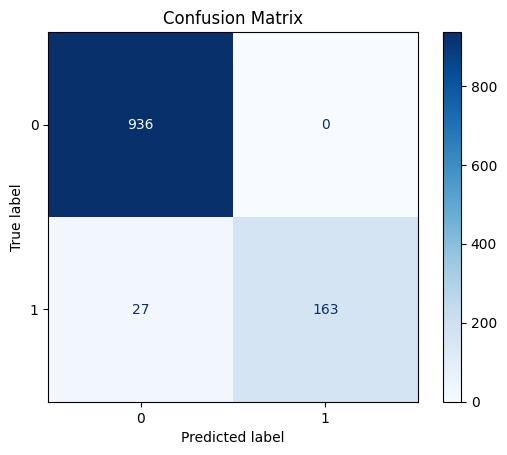

In [35]:
#Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [36]:
#Classification Report

print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       936
           1       1.00      0.86      0.92       190

    accuracy                           0.98      1126
   macro avg       0.99      0.93      0.95      1126
weighted avg       0.98      0.98      0.98      1126



In [37]:
#Feature Count After Encoding

print("Original Features :", len(X.columns))

transformed = model_pipeline.named_steps[
    "preprocessor"
].fit_transform(X_train)

print("Features After Encoding :", transformed.shape[1])

Original Features : 18
Features After Encoding : 34


In [39]:
#Save the Pipeline
import os
import joblib

# Define the file path
output_path = "../models/customer_churn_pipeline.pkl"

# Automatically create the folder if it does not exist
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# Save the Pipeline
joblib.dump(model_pipeline, output_path)

print("Pipeline saved successfully!")


Pipeline saved successfully!


In [40]:
#Load the Pipeline

loaded_pipeline = joblib.load(
    "../models/customer_churn_pipeline.pkl"
)

print("Pipeline loaded successfully!")

Pipeline loaded successfully!


In [41]:
#Predict a New Customer

new_customer = pd.DataFrame({

    "Tenure": [6],

    "CityTier": [1],

    "WarehouseToHome": [12],

    "PreferredLoginDevice": ["Mobile Phone"],

    "PreferredPaymentMode": ["Debit Card"],

    "Gender": ["Female"],

    "HourSpendOnApp": [3],

    "NumberOfDeviceRegistered": [4],

    "PreferedOrderCat": ["Laptop & Accessory"],

    "SatisfactionScore": [3],

    "MaritalStatus": ["Single"],

    "NumberOfAddress": [2],

    "Complain": [1],

    "OrderAmountHikeFromlastYear": [12],

    "CouponUsed": [2],

    "OrderCount": [3],

    "DaySinceLastOrder": [5],

    "CashbackAmount": [180]

})

In [42]:
#Predict

prediction = loaded_pipeline.predict(
    new_customer
)

probability = loaded_pipeline.predict_proba(
    new_customer
)

print("Prediction :", prediction)

print("Probability :", probability)

Prediction : [0]
Probability : [[0.95 0.05]]


In [43]:
print(f"Accuracy: {accuracy:.4f}")

print(classification_report(y_test, y_pred))

Accuracy: 0.9760
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       936
           1       1.00      0.86      0.92       190

    accuracy                           0.98      1126
   macro avg       0.99      0.93      0.95      1126
weighted avg       0.98      0.98      0.98      1126

